**Explanatory Data Analysis**

In [37]:
import pandas as pd

In [38]:
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

In [39]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [40]:
df.shape# to get the idea of the dimension of the dataset.

(2111, 17)

In [41]:
df.dtypes # checking data types of each coloumns. 

Gender                                str
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight        str
FAVC                                  str
FCVC                              float64
NCP                               float64
CAEC                                  str
SMOKE                                 str
CH2O                              float64
SCC                                   str
FAF                               float64
TUE                               float64
CALC                                  str
MTRANS                                str
NObeyesdad                            str
dtype: object

In [42]:
df.isnull().sum() #looking for missing values in the each coloumns.

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [43]:
df.memory_usage(deep=True)

Index                                132
Gender                            113969
Age                                16888
Height                             16888
Weight                             16888
family_history_with_overweight    109387
FAVC                              109527
FCVC                               16888
NCP                                16888
CAEC                              122164
SMOKE                             107705
CH2O                               16888
SCC                               107757
FAF                                16888
TUE                                16888
CALC                              118032
MTRANS                            141708
NObeyesdad                        137621
dtype: int64

In [44]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [45]:
unique_NObeyesdad = df["NObeyesdad"].unique()
unique_NObeyesdad

<StringArray>
[      'Normal_Weight',  'Overweight_Level_I', 'Overweight_Level_II',
      'Obesity_Type_I', 'Insufficient_Weight',     'Obesity_Type_II',
    'Obesity_Type_III']
Length: 7, dtype: str

In [46]:
unique_MTRANS = df["MTRANS"].unique()
print(unique_MTRANS)

<StringArray>
['Public_Transportation', 'Walking', 'Automobile', 'Motorbike', 'Bike']
Length: 5, dtype: str


In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

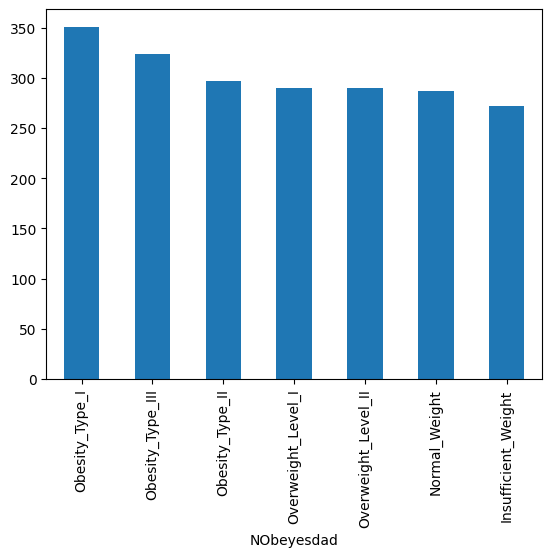

In [48]:
df['NObeyesdad'].value_counts().plot(kind='bar')
plt.show()

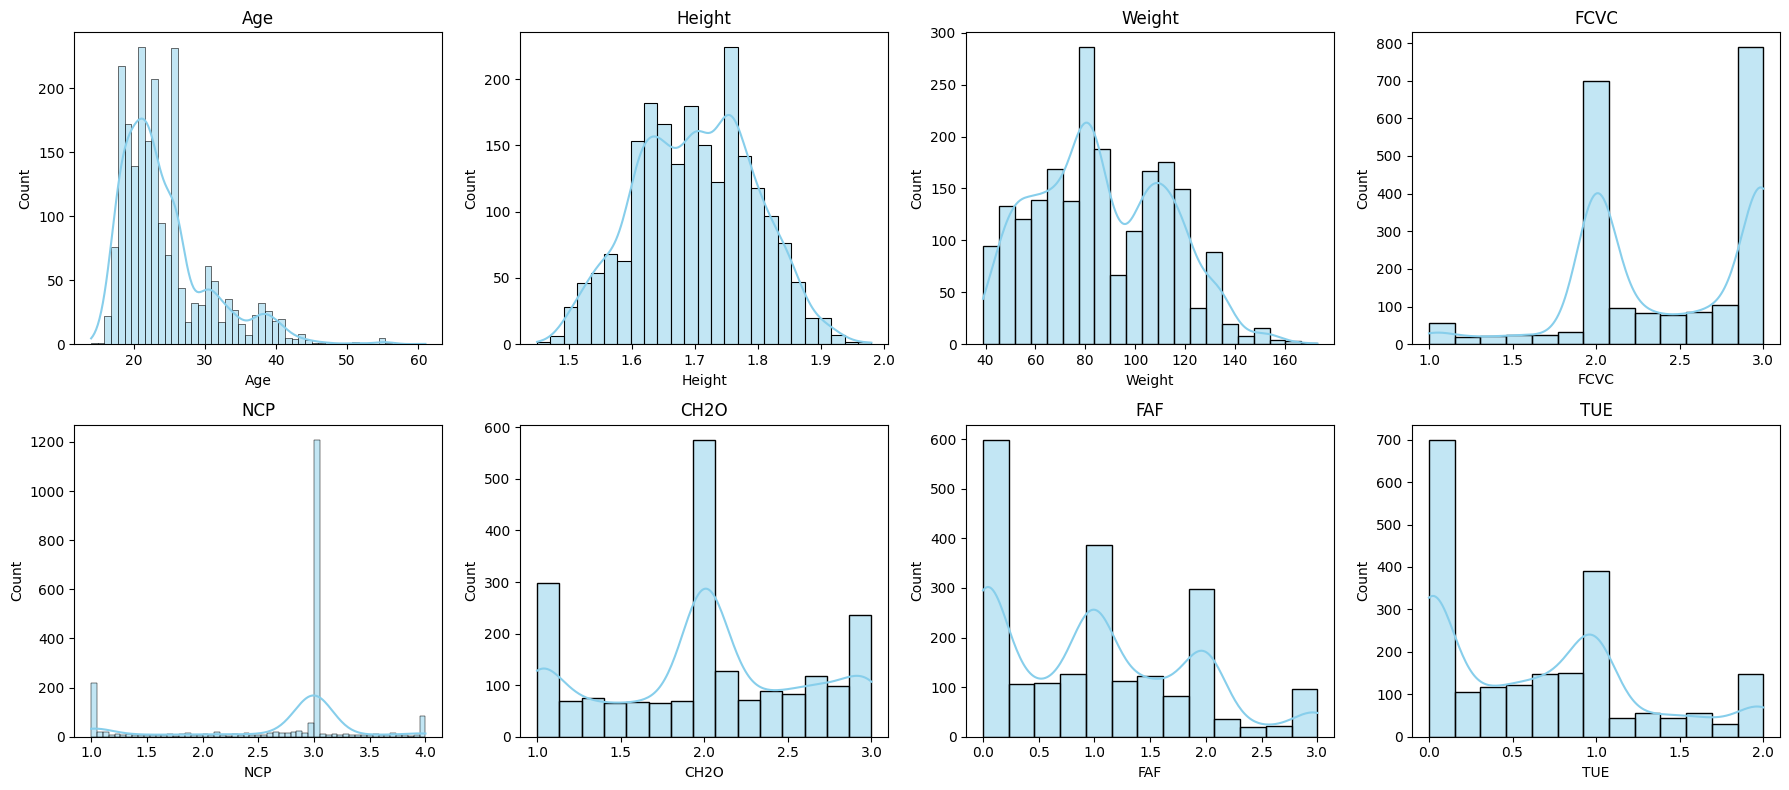

In [49]:
numeric_cols = ['Age', 'Height', 'Weight','FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

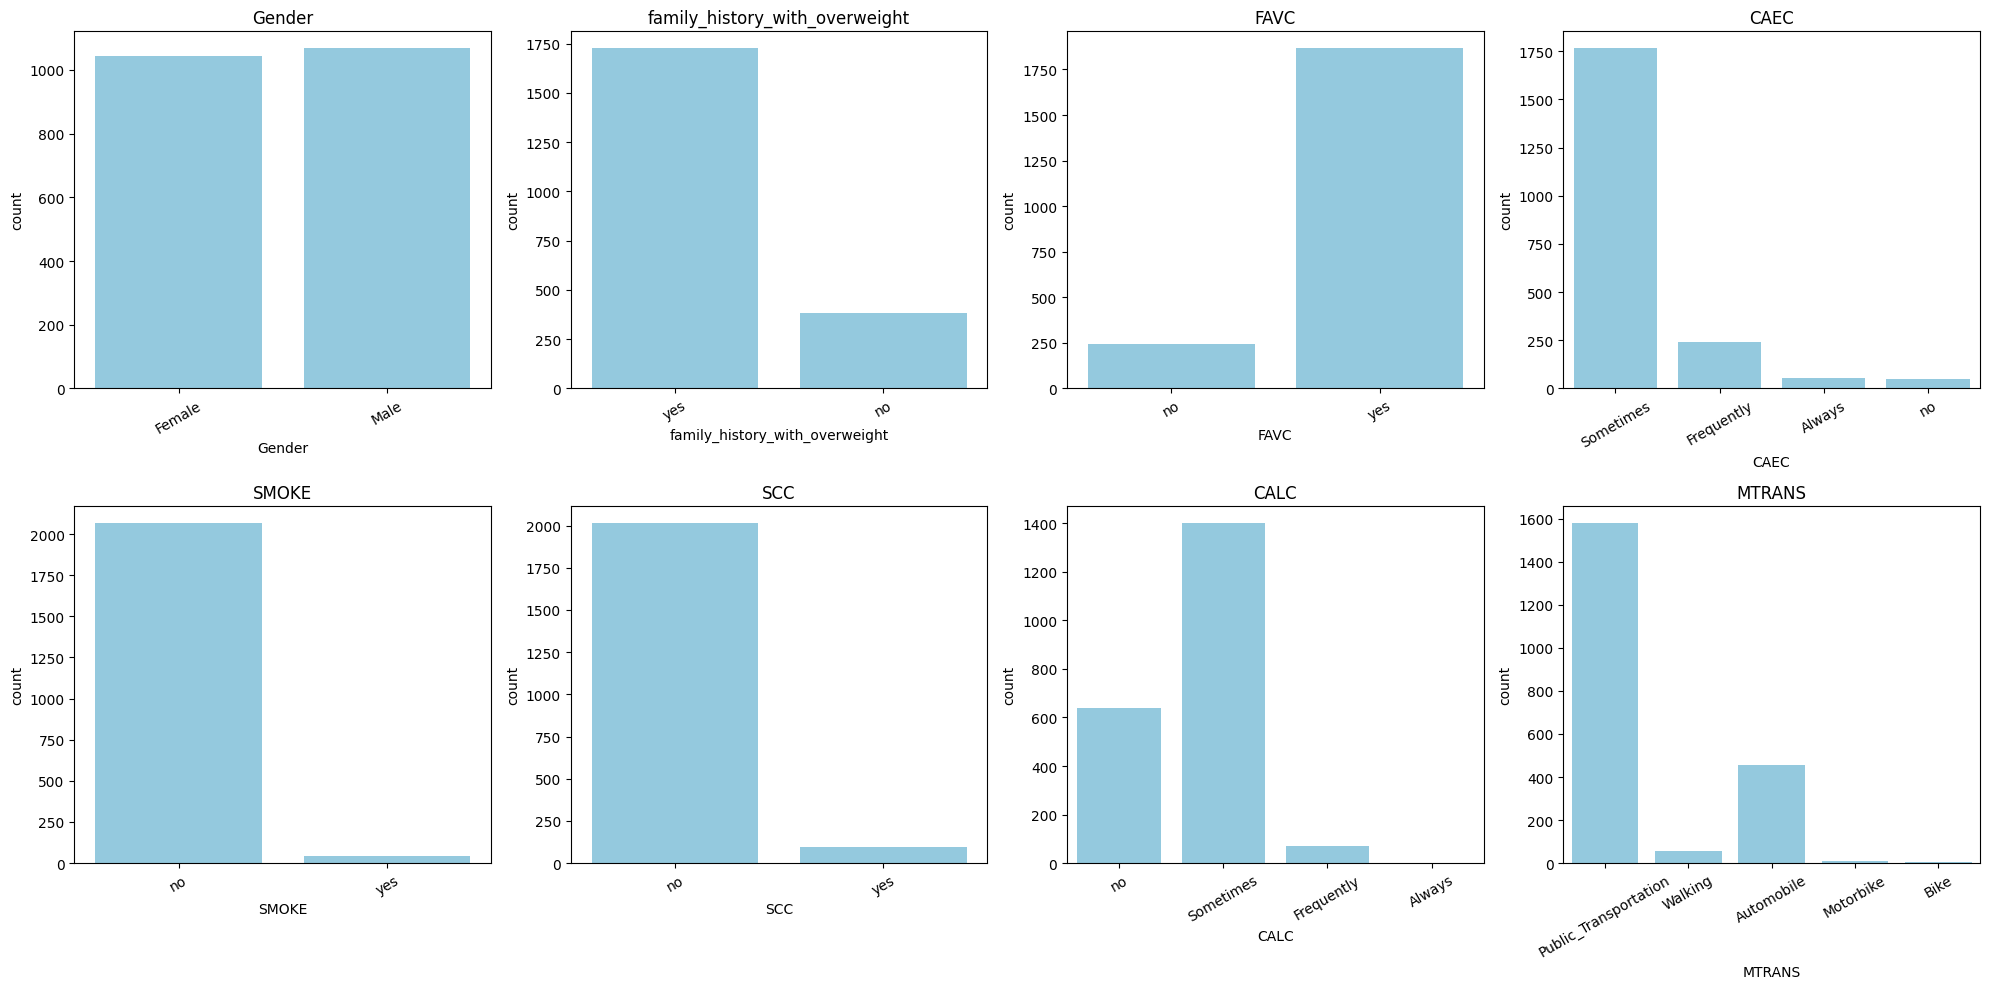

In [50]:
cat_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], color='skyblue')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

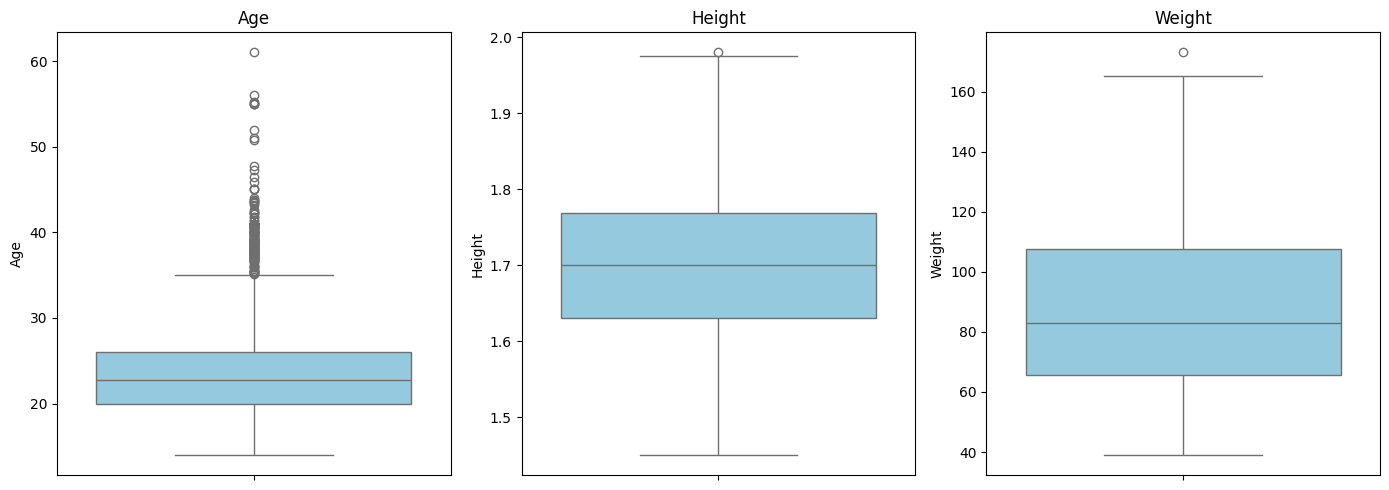

In [51]:
cols = ['Age', 'Height', 'Weight']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

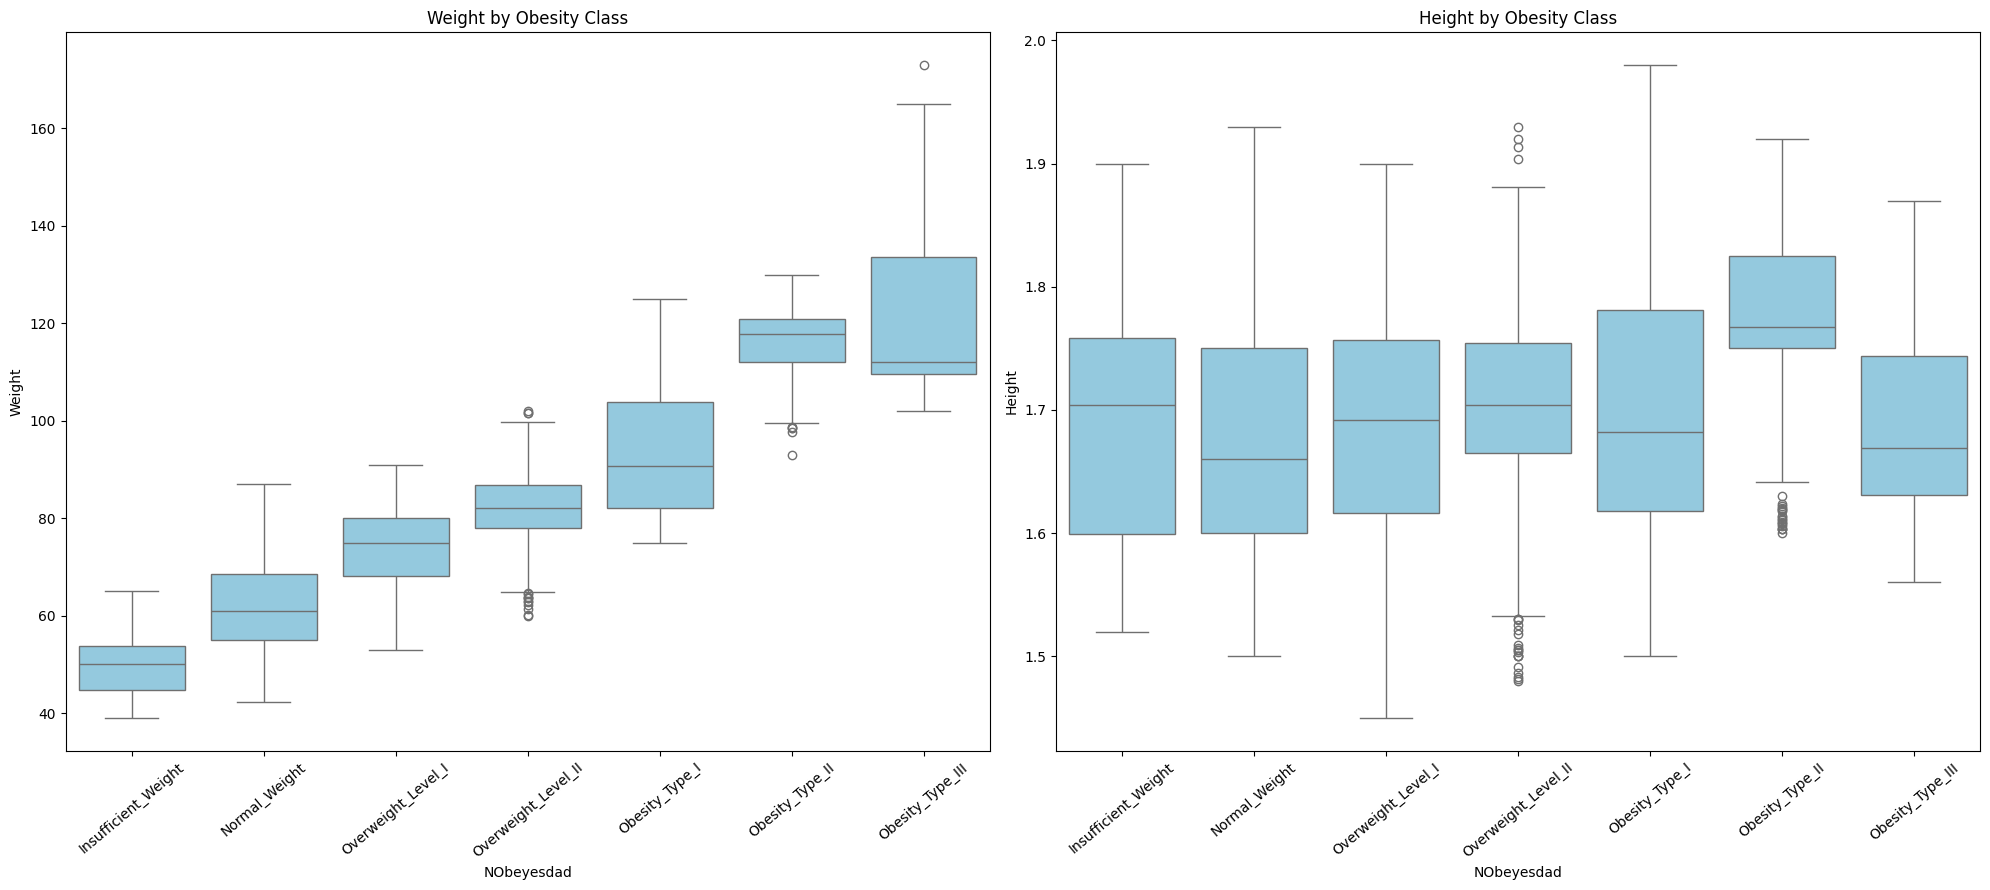

In [52]:
class_order = ['Insufficient_Weight','Normal_Weight','Overweight_Level_I','Overweight_Level_II',
               'Obesity_Type_I','Obesity_Type_II','Obesity_Type_III']

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

sns.boxplot(data=df, x='NObeyesdad', y='Weight', order=class_order, ax=axes[0], color='skyblue')
axes[0].set_title('Weight by Obesity Class')
axes[0].tick_params(axis='x', rotation=40)

sns.boxplot(data=df, x='NObeyesdad', y='Height', order=class_order, ax=axes[1], color='skyblue')
axes[1].set_title('Height by Obesity Class')
axes[1].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.show()

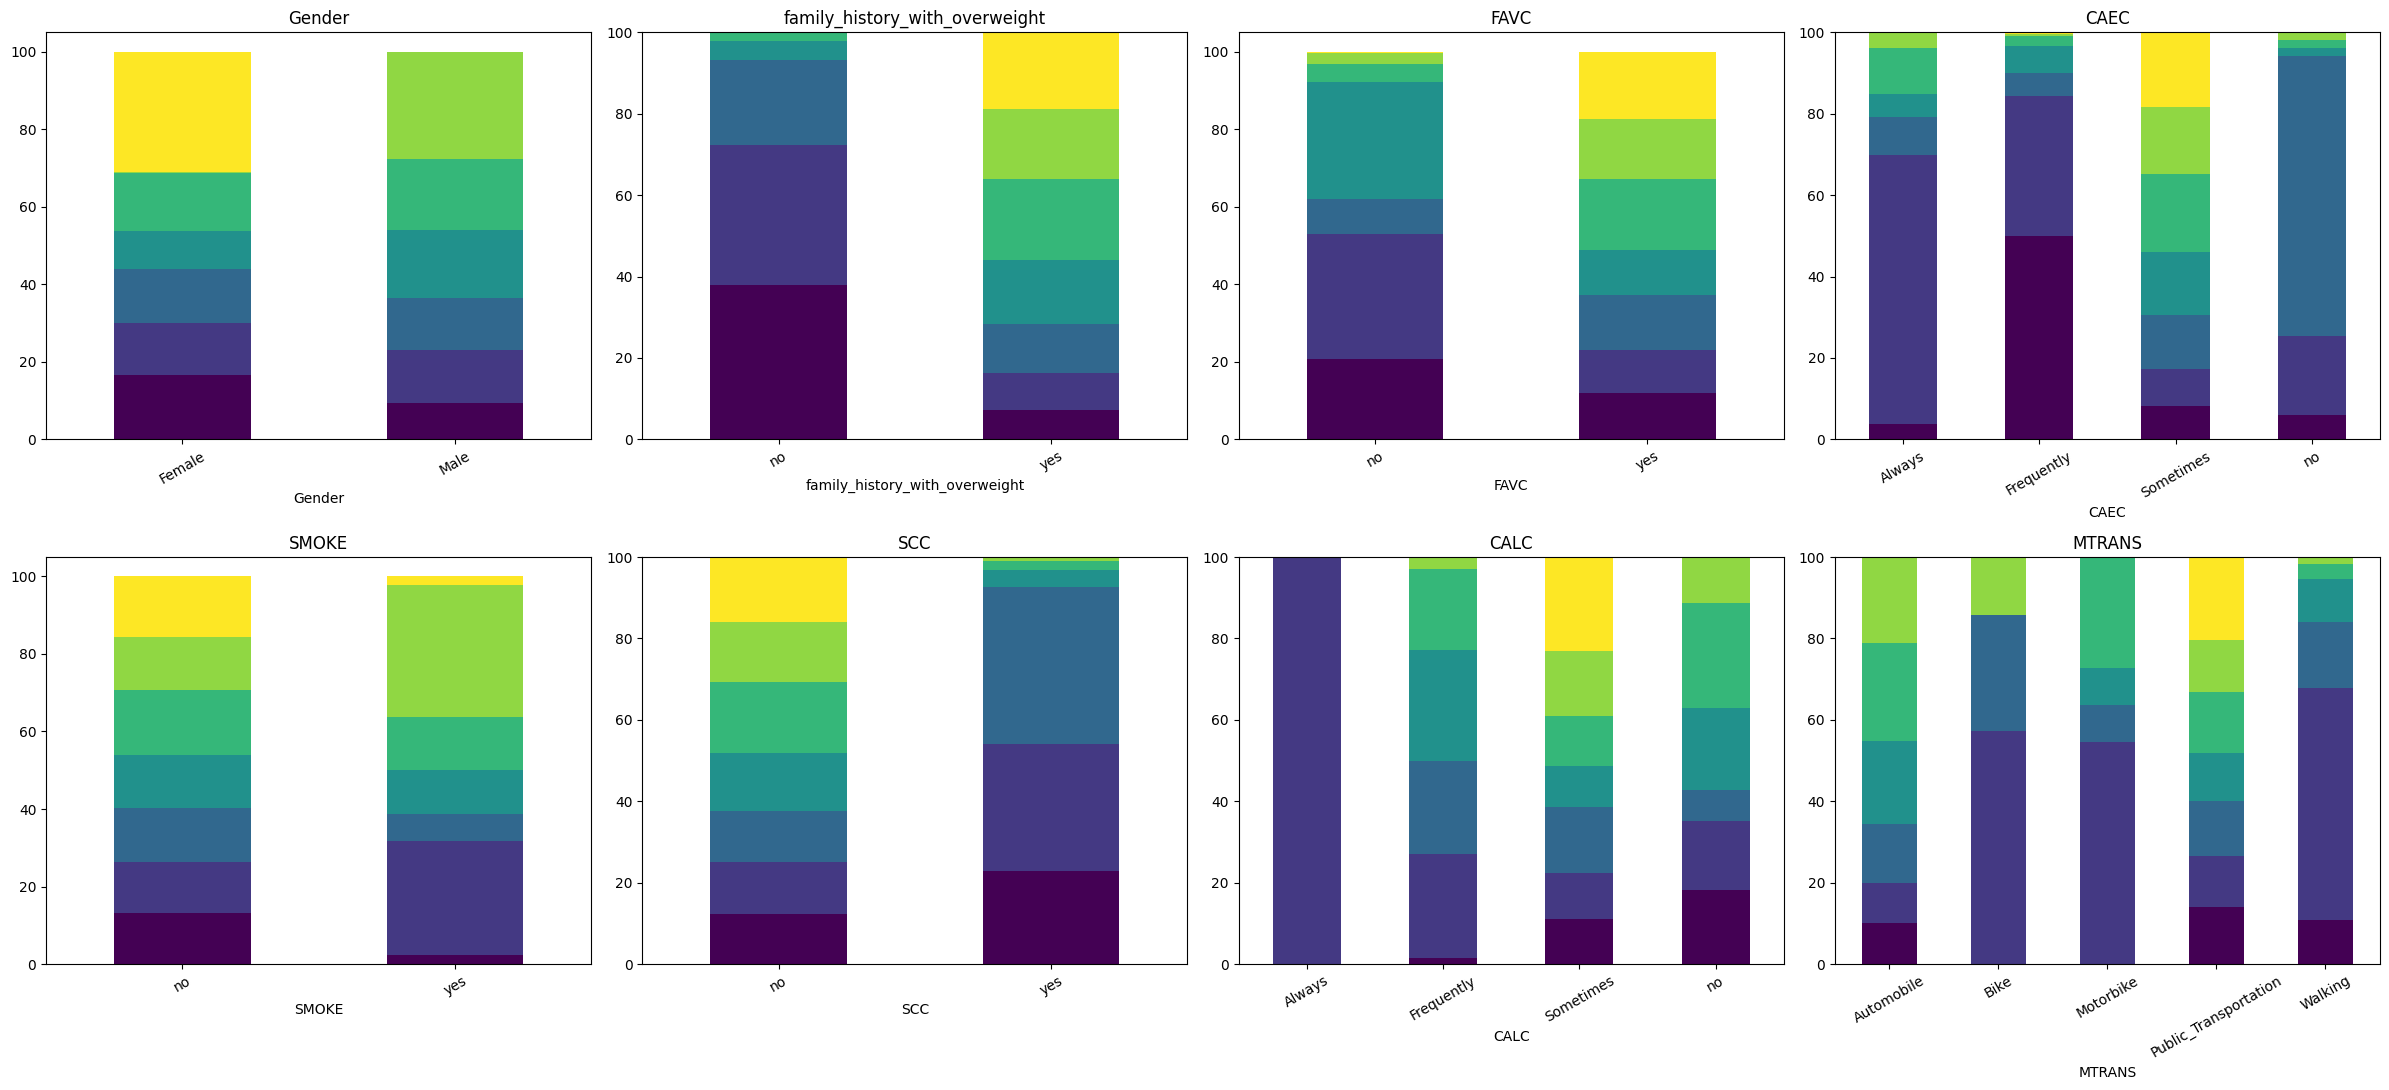

In [53]:
class_order = ['Insufficient_Weight','Normal_Weight','Overweight_Level_I','Overweight_Level_II',
               'Obesity_Type_I','Obesity_Type_II','Obesity_Type_III']

cat_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

fig, axes = plt.subplots(2, 4, figsize=(24, 11))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['NObeyesdad'])
    ct = ct[class_order]
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100  # turn counts into %
    ct_pct.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis', legend=False)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

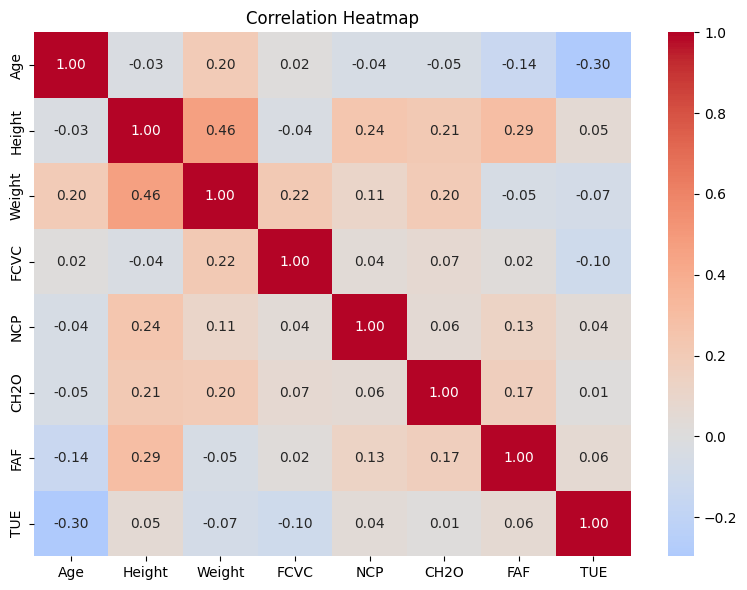

In [54]:
#Correlation heatmap#
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

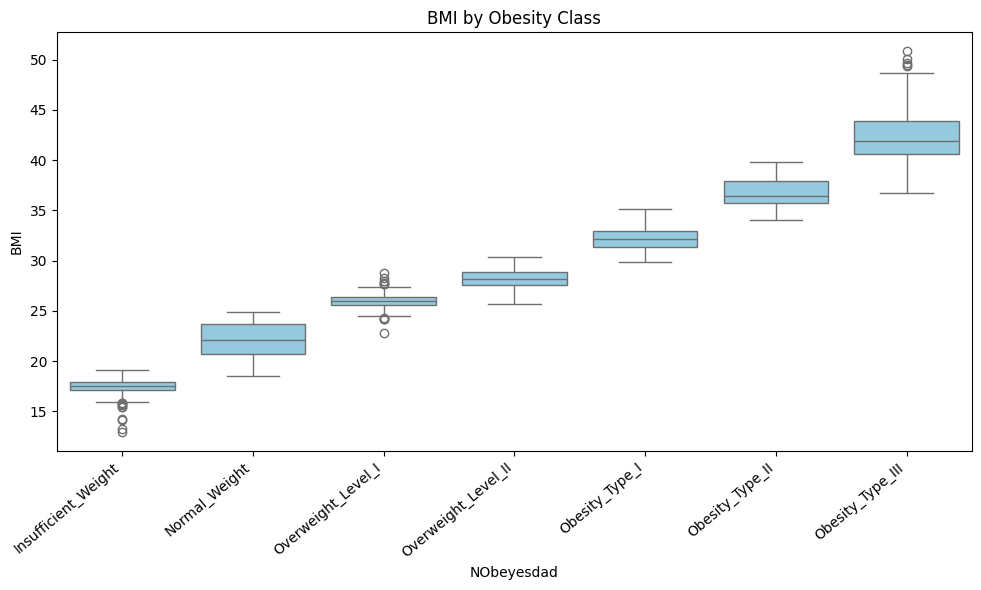

In [55]:
class_order = ['Insufficient_Weight','Normal_Weight','Overweight_Level_I','Overweight_Level_II',
               'Obesity_Type_I','Obesity_Type_II','Obesity_Type_III']

# create BMI = weight divided by height squared
df['BMI'] = df['Weight'] / (df['Height'] ** 2)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='NObeyesdad', y='BMI', order=class_order, color='skyblue')
plt.title('BMI by Obesity Class')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()